In [1]:
import os, sys

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not os.path.exists("Scaling-book"):
        !git clone https://github.com/arjuns238/Scaling-book.git
    %cd Scaling-book/Addition_Transformer
    !pip install -q flax optax

Cloning into 'Scaling-book'...
remote: Enumerating objects: 133, done.
remote: Counting objects: 100% (133/133), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 133 (delta 85), reused 74 (delta 29), pack-reused 0 (from 0)
Receiving objects: 100% (133/133), 348.26 KiB | 7.74 MiB/s, done.
Resolving deltas: 100% (85/85), done.
/content/Scaling-book/Addition_Transformer


In [2]:
import jax
jax.devices()

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


[TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]

In [3]:
# # chose configs - ~10M params
from model import *
from data import build_dataset, generate_split, Dataloader
import numpy as np
from config import Config
base_cfg = Config(
    d_model=384,
    ffw_multiplier=8/3,
    num_layers=6,
    query_heads=6,
    kv_heads=6,
    key_dim=64,
    vocab_size=16,
    batch_size = 256,
    num_experts = 8,   # > 0 selects the moe ffw; 0 would run the dense path
    top_k = 2,
    lb_factor = 0.01,
    dtype=jnp.bfloat16,
    lr = 1e-3,
    num_epochs = 15,
)

In [4]:
from utils import *

# Precompute (d_model, num_layers, N) once so we can pick sizes by N.
def size_table(base, SIZE_LADDER):
    table = []
    for dm, nl in SIZE_LADDER:
        w = Weights.init(make_cfg(base, dm, nl), jax.random.key(0))
        table.append((dm, nl, count_params(w)))
    return table  # list of (d_model, num_layers, N)

The smallest model is N=100,416. 

With N_min = 100416 and SUP_PER_EX ≈ 4 ( supervised tokens per example —, it's roughly the answer digits + EOS, so ~4 for the 2-and-3-digit-dominated draw).

The hard ceiling is distinct non-fundamental pairs: ~999,900. Fundamental pairs are defined as the cases with 1-digit addition as they are the fundamentals for all other cases. These are excluded from loss calculation.

To stay single-epoch (all fresh data, clean Chinchilla regime), the largest feasible budget for the smallest model:

C_max <= 6 * N_min * SUP_PER_EX * POOL_EXAMPLES
      =  6 * 100416 * 4 * 999900
      ≈  2,409,743,001,600
      ≈  2.4e12

# PART 2

In [4]:
import json, time

# --- persist ---------------------------------------------------------------
# The Colab VM is ephemeral: anything written to /content disappears when the
# runtime recycles (this is how the previous rows.pkl was lost). Copy to Drive.
def save_rows(rows, D_ceiling, tag):
    def _jsonable(r):
        return {k: (v.tolist() if hasattr(v, 'tolist') else v) for k, v in r.items()}

    arms = sorted({r.get('n_experts', 0) for r in rows})
    if tag == 'moe' and 0 in arms and len(arms) > 1:
        print("[!] these rows mix the dense arm into a 'moe' save. Save the moe "
              "sweep on its own and merge at analysis time instead.")
    if tag == 'dense' and any(a != 0 for a in arms):
        print(f"[!] non-dense arms {arms} in a 'dense' save.")

    stamp = time.strftime('%Y%m%d-%H%M%S')
    path = f"rows_{tag}_{stamp}.json"
    payload = dict(rows=[_jsonable(r) for r in rows], D_ceiling=D_ceiling,
                   tag=tag, stamp=stamp)
    with open(path, "w") as f:
        json.dump(payload, f)
    print(f"saved {len(rows)} rows -> {path}")

    if IN_COLAB:
        from google.colab import drive
        import shutil, os
        if not os.path.exists('/content/drive'):
            drive.mount('/content/drive')
        dest_dir = '/content/drive/MyDrive/scaling-book'
        os.makedirs(dest_dir, exist_ok=True)
        shutil.copy(path, dest_dir)
        print(f"copied -> {dest_dir}/{path}")
    return path



In [21]:
import jax
import jax.numpy as jnp
import numpy as np
import optax
from scipy.optimize import least_squares
from config import Config

BATCH_SIZE     = 256
SEED           = 0
VAL_SUP_TOKENS = 100_000      # fixed val set, counted in supervised tokens
MAX_LEN        = 14
MAX_N          = 1000         # operands 0..999

# model ladder: (d_model, num_layers). Two small rungs added at the bottom.
# At D=4.3M the old ladder's losses spanned only 0.048 -> 0.007 across N - all four
# models had essentially solved the task, so alpha was being fitted from four
# numbers clustered on the floor. Models this small stay above the floor and give
# the N direction real signal.
MODEL_LADDER = [(32, 2), (48, 2), (64, 2), (96, 3),
                (128, 3), (192, 4), (256, 5), (384, 6)]

# per-model-size peak LR, held fixed across D. Generated by a rule rather than a
# hand table so new rungs cannot be forgotten; anchored on the old values
# ((64,2)=1.5e-3, (384,6)=5e-4 sit within a few percent of this curve).
def peak_lr(d_model):
    return 1.5e-3 * (64.0 / d_model) ** 0.5

PEAK_LR = {(dm, nl): peak_lr(dm) for dm, nl in MODEL_LADDER}

# compute budgets for the isoFLOP design. Defined here, with the other ladders,
# rather than inside the sweep cell - the analysis cells need it too, and it must
# survive reloading a saved sweep without retraining.
#
# These three came from binning the dense grid's C range. Judged against what that
# grid then showed, only 1.8e13 lands inside the measurable window (0.02 < L < 1.4):
# 1.8e12 is mostly guessing plateau and 1.8e14 is fully saturated (~4e-4).
# [3e12, 8e12, 2e13] would keep all three budgets usable.
C_TARGETS = [1.8e12, 1.8e13, 1.8e14]

# data ladder in SUPERVISED tokens. Log-spaced across the window that survives the
# fit-range filter, rather than spanning the full range and losing most of it:
#   below ~575k a single epoch at batch 256 is under 500 optimizer steps
#     -> undertrained, not data-limited (the old 100k and 250k rungs)
#   above ~4.3M the pool is exhausted, and the top rungs are already at the floor
#     (beta between 2.8M and 4.3M measured -0.17, +0.44, +4.89 = noise)
# 8 rungs inside the window beats 6 spanning three regimes.
DATA_LADDER = [600_000, 795_000, 1_055_000, 1_400_000,
               1_850_000, 2_450_000, 3_250_000, 4_300_000]

In [10]:
# ============================================================================
# 1. Pool construction, fixed val carve, nested prefixes
# ============================================================================
from data import create_example

def build_pool(seed=SEED):
    """All non-fundamental pairs, shuffled once. Fundamentals = both operands
    single-digit (a<10 and b<10) -> memorized lookup, excluded."""
    toks, masks = [], []
    for a in range(MAX_N):
        for b in range(MAX_N):
            if a < 10 and b < 10:
                continue
            t, m = create_example(a, b, MAX_LEN)
            toks.append(t)
            masks.append(m)
    toks  = np.asarray(toks,  dtype=np.int32)
    masks = np.asarray(masks, dtype=np.int32)
    perm = np.random.default_rng(seed).permutation(len(toks))
    return toks[perm], masks[perm]

def supervised_tokens(masks):
    return int(masks.sum())


def carve_val(pool_tok, pool_mask, val_sup_tokens=VAL_SUP_TOKENS):
    """Fixed val set taken from the front of the shuffled pool; the remainder
    is the training pool. Val is identical for every cell."""
    cum = np.cumsum(pool_mask.sum(axis=1))
    n_val = int(np.searchsorted(cum, val_sup_tokens) + 1)
    return (pool_tok[:n_val], pool_mask[:n_val],
            pool_tok[n_val:], pool_mask[n_val:])


def prefix_for_D(tr_tok, tr_mask, D_sup_tokens):
    """Nested prefix: fewest examples whose supervised tokens reach D."""
    cum = np.cumsum(tr_mask.sum(axis=1))
    n = min(int(np.searchsorted(cum, D_sup_tokens) + 1), len(tr_tok))
    return tr_tok[:n], tr_mask[:n]


def check_ladder(tr_mask, ladder=DATA_LADDER):
    """Verify every D is actually available; return the ceiling."""
    avail = supervised_tokens(tr_mask)
    print(f"train pool supervised tokens available: {avail:,}")
    for D in ladder:
        print(f"  D={D:>10,}  {'ok' if D <= avail else 'EXCEEDS POOL'}")
    if max(ladder) > avail:
        raise ValueError(
            f"largest D ({max(ladder):,}) exceeds pool ({avail:,}). "
            "Lower the top of DATA_LADDER.")
    return avail

In [6]:
# ============================================================================
# 2. Config / param counting
# ============================================================================
from utils import active_params, check_param_formula

def make_cfg(base_cfg: Config, d_model, num_layers):
    """Scale heads with d_model, keeping key_dim pinned at 64.

    The previous version held heads at base_cfg's 6, so a d_model=32 model still
    carried 6x64 attention: 4DHL dominated and N bottomed out at ~116k no matter
    how small d_model got. Scaling heads makes the small rungs genuinely small
    (33k instead of 116k) and widens the ladder from 1.6 to 2.5 decades of N -
    which is what alpha is estimated from.
    """
    heads = max(1, d_model // base_cfg.key_dim)
    return base_cfg.replace(d_model=d_model, num_layers=num_layers,
                            query_heads=heads, kv_heads=heads)


def count_params(cfg: Config):
    """N for the 6ND compute model = ACTIVE params (3LDFK + 4DHL + 2DV).

    Counting every leaf would include the idle experts, which cost memory but
    no flops - at E=8/K=2 that inflates N by ~5.7x and makes the moe frontier
    incomparable to the dense one. See utils.active_params."""
    return active_params(cfg)


# the formula omits norm gammas and pos_embed; on a dense cfg the leftover should be
# small and constant-ish. run once so a Layer change can't silently desync N.
_probe = base_cfg.replace(num_experts=0)
_f, _a, _d = check_param_formula(_probe)
print(f"dense probe: formula {_f:,} vs pytree {_a:,} -> delta {_d:,} (norms + pos_embed)")
print(f"moe N (active) at base shape: {count_params(base_cfg):,}")

dense probe: formula 10,629,120 vs pytree 10,634,112 -> delta 4,992 (norms + pos_embed)
moe N (active) at base shape: 17,707,008


In [7]:
# ============================================================================
# 3. Train one (N, D) cell — single epoch, matched cosine
# ============================================================================
import optax
from optax.losses import softmax_cross_entropy_with_integer_labels

def make_optimizer(peak_lr, total_steps, weight_decay=0.1):
    schedule = optax.warmup_cosine_decay_schedule(
        init_value=0.0,
        peak_value=peak_lr,
        # proportional warmup, capped at 50. The old max(50, ...) put 58% of a short
        # run into warmup, so small-D cells never trained at peak LR and flat-lined
        # at ~1.55 - which looked like a phase transition in the loss surface. It also
        # made decay_steps negative below 50 steps, killing those cells outright.
        warmup_steps=max(1, min(50, int(0.05 * total_steps))),
        decay_steps=total_steps,
        end_value=peak_lr * 0.1,
    )
    return optax.adamw(schedule, weight_decay=weight_decay)


def calc_val_loss(val_loader, weights, cfg):
    # report CE only - the lb term is a training regularizer, not part of the loss surface we fit
    losses = [loss_fn(weights, x, m, cfg)[1]['ce'].item() for x, m in val_loader]
    return float(np.mean(losses))

def loss_fn(weights: jax.Array, token_ids: jax.Array, mask: jax.Array, cfg: Config) -> jax.Array:
    logits, lb, _stats = forward(token_ids[:, :-1], weights, cfg)
    targets = token_ids[:, 1:]
    # for addition, we need to build a mask because the model needs to only predict the last 3 digits
    # need mask code
    loss_mask = mask[:, 1:]
    ce = softmax_cross_entropy_with_integer_labels(logits, targets) # mean would also change since masking the outputs
    ce = jnp.sum(ce * loss_mask) / jnp.sum(loss_mask)
    loss = ce + cfg.lb_factor * lb
    return loss, dict(ce = ce, lb = lb)


# ----------------------------------------------------------------------------
# 3b. Routing diagnostics — logged on EVERY run
# ----------------------------------------------------------------------------
# Without these a fit can look clean and be measuring the wrong thing: "moe scales
# worse at high E" and "my router collapsed at high E" produce the same loss curve.
# frac tells you batch-level balance, entropy tells you per-token confidence.
def collect_routing(weights, cfg, loader):
    """Average the per-layer router diagnostics over a loader. Returns None for a
    dense cfg (no router to report on)."""
    if cfg.num_experts == 0:
        return None

    @jax.jit
    def stats_for(x):
        _logits, _lb, stats = forward(x[:, :-1], weights, cfg)
        return stats

    frac_sum, ent_sum, n_batches = None, None, 0
    for x, _m in loader:
        stats = stats_for(x)
        f = np.stack([np.asarray(s['frac']) for s in stats])         # (L, E)
        e = np.array([float(s['entropy']) for s in stats])           # (L,)
        frac_sum = f if frac_sum is None else frac_sum + f
        ent_sum  = e if ent_sum  is None else ent_sum + e
        n_batches += 1

    frac = frac_sum / n_batches      # (L, E) fraction of dispatch slots per expert
    ent  = ent_sum / n_batches       # (L,)   nats
    uniform = 1.0 / cfg.num_experts

    return dict(
        frac=frac,                                   # full (L, E) table, kept for plots
        entropy=ent,
        max_frac=float(frac.max()),                  # 1/E balanced, ->1 collapsed
        min_frac=float(frac.min()),
        # share of experts receiving < 10% of their uniform allocation = effectively dead
        dead_frac=float((frac < 0.1 * uniform).mean()),
        mean_entropy=float(ent.mean()),
        # 1.0 = uniform routing, 0.0 = every token fully committed to one expert
        entropy_norm=float(ent.mean() / np.log(cfg.num_experts)),
        imbalance=float(frac.max() / uniform),       # 1.0 balanced, E = full collapse
    )


# Single-seed noise currently exceeds the trend: at D=600k the dense losses ran
# 0.62, 0.33, 1.54, 0.23, 0.13 as N increased - that 1.54 is a failed run, not a
# data point. Median over seeds is what makes the surface measurable.
# Set to (0, 1, 2) to take a median over seeds if outliers reappear.
SEEDS = (0,)


def train_cell(base_cfg, d_model, num_layers, tr_tok, tr_mask,
               val_tok, val_mask, seeds=SEEDS):
    losses, routings = [], []
    for sd in seeds:
        vl, rt = _train_one(base_cfg, d_model, num_layers, tr_tok, tr_mask,
                            val_tok, val_mask, sd)
        losses.append(vl)
        if rt is not None:
            routings.append(rt)

    val_loss = float(np.median(losses))
    spread = float(max(losses) - min(losses))
    # routing diagnostics from the seed closest to the median loss
    routing = routings[int(np.argmin(np.abs(np.array(losses) - val_loss)))] if routings else None
    return val_loss, routing, spread, len(losses)


def _train_one(base_cfg, d_model, num_layers, tr_tok, tr_mask,
               val_tok, val_mask, seed=SEED):
    cfg = make_cfg(base_cfg, d_model, num_layers)
    total_steps = len(tr_tok) // BATCH_SIZE      # single epoch
    if total_steps < 1:
        raise ValueError(f"D too small for one batch: {len(tr_tok)} examples")

    weights = Weights.init(cfg, jax.random.key(seed))
    opt = make_optimizer(PEAK_LR[(d_model, num_layers)], total_steps)
    opt_state = opt.init(weights)

    @jax.jit
    def train_step(x, mask, weights, opt_state):
        # cfg is closed over, so it stays a python constant under jit (num_experts/top_k must be static)
        (loss, aux), grads = jax.value_and_grad(loss_fn, has_aux=True)(weights, x, mask, cfg)
        updates, opt_state = opt.update(grads, opt_state, weights)
        weights = optax.apply_updates(weights, updates)
        return loss, aux, weights, opt_state

    for x, m in Dataloader(tr_tok, tr_mask, BATCH_SIZE):
        _, aux, weights, opt_state = train_step(x, m, weights, opt_state)

    val_loader = Dataloader(val_tok, val_mask, BATCH_SIZE, shuffle=False)
    val_loss = calc_val_loss(val_loader, weights, cfg)
    routing = collect_routing(
        weights, cfg, Dataloader(val_tok, val_mask, BATCH_SIZE, shuffle=False))
    return val_loss, routing

In [13]:
# ============================================================================
# 4. LEGACY: full-cross (E, N, D) grid sweep
# ============================================================================
# Superseded by the isoFLOP sweep in section 4b. Kept because the dense arm was
# collected this way. The grid caps D at the unique pool (DATA_LADDER max 4.3M),
# produces diagonal isoFLOP lines whose extreme bands hold one or two models, and
# costs ~5x more runs per arm. Do not use it for a fresh arm.
# top_k is fixed at 2 (base_cfg), so E is the only routing variable.
# 0 = dense is NOT in this ladder: the dense arm lives in chinchilla_laws_dense
# and is loaded for comparison rather than retrained here. Add 0 back if you want
# a dense control trained under identical conditions in this notebook.
E_LADDER = [2, 8, 16]


def run_sweep(base_cfg, e_ladder=E_LADDER, seed=SEED):
    pool_tok, pool_mask = build_pool(seed)
    val_tok, val_mask, tr_tok, tr_mask = carve_val(pool_tok, pool_mask)

    print(f"pool: {len(pool_tok):,} ex, {supervised_tokens(pool_mask):,} sup-tok")
    print(f"val:  {len(val_tok):,} ex, {supervised_tokens(val_mask):,} sup-tok")
    D_ceiling = check_ladder(tr_mask)
    print(f"\ncells to run: {len(e_ladder)} E x {len(MODEL_LADDER)} N x {len(DATA_LADDER)} D "
          f"= {len(e_ladder)*len(MODEL_LADDER)*len(DATA_LADDER)}\n")

    rows = []
    for E in e_ladder:
        cfg_E = base_cfg.replace(num_experts=E)
        tag = "dense" if E == 0 else f"E={E}"
        print(f"--- {tag} " + "-" * 60)
        for (d_model, num_layers) in MODEL_LADDER:
            N = count_params(make_cfg(cfg_E, d_model, num_layers))   # ACTIVE params
            for D in DATA_LADDER:
                sub_tok, sub_mask = prefix_for_D(tr_tok, tr_mask, D)
                D_actual = supervised_tokens(sub_mask)
                val_loss, routing, spread, n_seeds = train_cell(
                    cfg_E, d_model, num_layers, sub_tok, sub_mask,
                    val_tok, val_mask)
                row = dict(n_experts=E, top_k=(cfg_E.top_k if E else 1),
                           d_model=d_model, num_layers=num_layers, N=N,
                           D_target=D, D_actual=D_actual, val_loss=val_loss,
                           seed_spread=spread, n_seeds=n_seeds,
                           n_examples=len(sub_tok),
                           steps=len(sub_tok) // BATCH_SIZE)
                if routing is not None:
                    row.update(max_frac=routing['max_frac'],
                               min_frac=routing['min_frac'],
                               dead_frac=routing['dead_frac'],
                               mean_entropy=routing['mean_entropy'],
                               entropy_norm=routing['entropy_norm'],
                               imbalance=routing['imbalance'],
                               frac=routing['frac'])
                rows.append(row)

                diag = ""
                if routing is not None:
                    diag = (f"  | imbal={routing['imbalance']:.2f}"
                            f" H/logE={routing['entropy_norm']:.2f}"
                            f" dead={routing['dead_frac']:.0%}")
                print(f"  N={N:>9,}  D={D_actual:>9,}  val={val_loss:.4f}"
                      f" (+/-{spread:.3f} over {n_seeds}){diag}")
    return rows, D_ceiling


def rows_where(rows, n_experts):
    # .get, not [] - rows saved before the arm was tagged (and any dense rows
    # merged in from the dense notebook) have no 'n_experts' key and are dense.
    return [r for r in rows if r.get('n_experts', 0) == n_experts]


def routing_table(rows, e_ladder=E_LADDER):
    """Per-E routing health, worst case over the (N, D) grid. Read this BEFORE the
    fits: a slice with imbalance near E or dead experts is measuring collapse, and
    its A is not a scaling result."""
    print(f"{'E':>4} {'runs':>5} {'imbal max':>10} {'H/logE min':>11} "
          f"{'dead max':>9} {'verdict':>28}")
    for E in e_ladder:
        sub = [r for r in rows_where(rows, E) if 'imbalance' in r]
        if not sub:
            continue
        imb = max(r['imbalance'] for r in sub)
        hn  = min(r['entropy_norm'] for r in sub)
        dead = max(r['dead_frac'] for r in sub)
        if imb > 0.5 * E or dead > 0.25:
            verdict = "COLLAPSED - fit not valid"
        elif imb > 2.0 or dead > 0.0:
            verdict = "skewed - interpret with care"
        else:
            verdict = "healthy"
        print(f"{E:>4} {len(sub):>5} {imb:>10.2f} {hn:>11.3f} {dead:>9.1%} {verdict:>28}")

In [13]:
# ============================================================================
# Multi-epoch infill — fill thin isoFLOP bands without retraining anything
# ============================================================================
# A rectangular (N, D) grid makes DIAGONAL isoFLOP lines, so the extreme compute
# bands always end up with one or two models. Reaching them with a smaller model
# needs D beyond the pool, i.e. repeats. Muennighoff et al. find up to ~4 epochs
# of repetition is worth roughly as much as fresh data, so MAX_EPOCHS=4 is the
# cap; past that the repeated tokens are worth measurably less and D stops meaning
# what the scaling law assumes.
#
# Everything here ADDS rows. train_cell and the existing sweep are untouched, so
# the cells you already have stay exactly as they were - which is the point:
# infill points must be comparable to the grid they are filling in.
#
# LR: peak LR stays a function of model size only (the same PEAK_LR the existing
# rows used). Retuning it here would make the new cells incomparable to the old.

MAX_EPOCHS = 4.0


def add_compute(rows, kappa=6.0):
    """Attach C = kappa*N*D to every row. Defined here as well as in the isoFLOP
    analysis cell so the sweep does not depend on that cell having been run."""
    for r in rows:
        r['C'] = kappa * r['N'] * r['D_actual']
    return rows


def cycling_loader(tok, mask, batch_size, n_steps, seed=0):
    """Yield exactly n_steps batches, reshuffling and cycling the pool as needed.
    Replaces the single-pass Dataloader when D exceeds the unique data."""
    rng = np.random.default_rng(seed)
    n = len(tok)
    steps = 0
    while steps < n_steps:
        idx = rng.permutation(n)
        for i in range(0, n - batch_size + 1, batch_size):
            if steps >= n_steps:
                return
            b = idx[i:i + batch_size]
            yield jnp.asarray(tok[b]), jnp.asarray(mask[b])
            steps += 1


def train_cell_D(base_cfg, d_model, num_layers, tr_tok, tr_mask,
                 val_tok, val_mask, D_target, seed=SEED):
    """Train one cell to a supervised-token budget D_target, repeating the pool if
    D_target exceeds it. Returns (val_loss, routing, n_epochs, steps)."""
    cfg = make_cfg(base_cfg, d_model, num_layers)
    sup_per_ex = float(tr_mask.sum() / len(tr_mask))
    pool_tokens = float(tr_mask.sum())
    n_epochs = D_target / pool_tokens
    if n_epochs > MAX_EPOCHS:
        raise ValueError(f"D={D_target:,.0f} needs {n_epochs:.1f} epochs "
                         f"(> MAX_EPOCHS={MAX_EPOCHS})")

    total_steps = int(D_target / sup_per_ex / BATCH_SIZE)
    if total_steps < 1:
        raise ValueError(f"D too small for one batch: {D_target}")

    weights = Weights.init(cfg, jax.random.key(seed))
    opt = make_optimizer(PEAK_LR[(d_model, num_layers)], total_steps)
    opt_state = opt.init(weights)

    # the dense notebook's loss_fn returns a scalar, the moe one returns
    # (loss, aux_dict). Unwrap at trace time so this works in both.
    def _scalar_loss(w, x, m, c):
        out = loss_fn(w, x, m, c)
        return out[0] if isinstance(out, tuple) else out

    @jax.jit
    def train_step(x, mask, weights, opt_state):
        loss, grads = jax.value_and_grad(_scalar_loss)(weights, x, mask, cfg)
        updates, opt_state = opt.update(grads, opt_state, weights)
        return loss, optax.apply_updates(weights, updates), opt_state

    for x, m in cycling_loader(tr_tok, tr_mask, BATCH_SIZE, total_steps, seed):
        _, weights, opt_state = train_step(x, m, weights, opt_state)

    val_loss = calc_val_loss(
        Dataloader(val_tok, val_mask, BATCH_SIZE, shuffle=False), weights, cfg)
    routing = collect_routing(
        weights, cfg, Dataloader(val_tok, val_mask, BATCH_SIZE, shuffle=False)) \
        if 'collect_routing' in globals() else None
    return val_loss, routing, n_epochs, total_steps


def plan_infill(rows, C_targets, model_ladder, pool_tokens, cfg=None, tol=0.18,
                max_epochs=MAX_EPOCHS, min_D=None, verbose=True):
    """Which (model, D) cells would thicken each compute band. Skips models already
    in the band and anything needing more than max_epochs.

    cfg selects the arm: N is computed for THAT config (so moe N is active params
    at its own num_experts), and only rows from the same arm count as 'already
    have'. Planning against all arms at once would both miscount coverage and plan
    cells for an arm you are not about to train.
    """
    cfg = base_cfg if cfg is None else cfg
    arm = getattr(cfg, 'num_experts', 0)
    rows_arm = [r for r in rows if r.get('n_experts', 0) == arm]
    add_compute(rows_arm)
    plan = []
    for C in C_targets:
        have = sorted({r['N'] for r in rows_arm if abs(np.log10(r['C'] / C)) <= tol})
        if verbose:
            tag = 'dense' if arm == 0 else f'E={arm}'
            print(f"[{tag}] C={C:.1e}: already have {len(have)} N")
        for dm, nl in model_ladder:
            N = count_params(make_cfg(cfg, dm, nl))
            if any(abs(np.log10(N / h)) < 1e-9 for h in have):
                continue
            D = C / (6.0 * N)
            ep = D / pool_tokens
            if ep > max_epochs or (min_D is not None and D < min_D):
                if verbose:
                    why = f"{ep:.1f} epochs" if ep > max_epochs else "D below ladder floor"
                    print(f"   skip  ({dm},{nl}) N={N:>10,}  {why}")
                continue
            plan.append(dict(C=C, d_model=dm, num_layers=nl, N=N, D=D,
                             epochs=ep, num_experts=arm))
            if verbose:
                print(f"   ADD   ({dm},{nl}) N={N:>10,}  D={D:>12,.0f}  {ep:>4.1f} epochs")
    if verbose and plan:
        print(f"\n{len(plan)} runs, {sum(6*p['N']*p['D'] for p in plan):.2e} FLOPs total")
    return plan


def run_infill(base_cfg, plan, rows, tr_tok, tr_mask, val_tok, val_mask, seed=SEED):
    """Train the planned cells and append them to rows. Returns the new rows only."""
    added = []
    for i, p in enumerate(plan, 1):
        print(f"[{i}/{len(plan)}] N={p['N']:,} D={p['D']:,.0f} ({p['epochs']:.1f} ep) ...",
              flush=True)
        vl, routing, ep, steps = train_cell_D(
            base_cfg, p['d_model'], p['num_layers'], tr_tok, tr_mask,
            val_tok, val_mask, p['D'], seed)
        row = dict(n_experts=getattr(base_cfg, 'num_experts', 0),
                   d_model=p['d_model'], num_layers=p['num_layers'], N=p['N'],
                   D_target=p['D'], D_actual=p['D'], val_loss=vl,
                   seed_spread=0.0, n_seeds=1, n_examples=len(tr_tok),
                   steps=steps, n_epochs=ep, infill=True)
        if routing is not None:
            row.update({k: routing[k] for k in
                        ('max_frac', 'min_frac', 'dead_frac', 'mean_entropy',
                         'entropy_norm', 'imbalance')})
        added.append(row)
        rows.append(row)
        print(f"      val_loss={vl:.4f}  steps={steps:,}")
    return added

# ----------------------------------------------------------------------------
# Direct isoFLOP sweep — design the budgets up front instead of grid + infill
# ----------------------------------------------------------------------------
# The grid-then-infill route was a consequence of running the grid first. Given the
# compute budgets you care about, it is strictly better to derive each cell:
# choose C, choose the model, and D = C/(6N) follows. Every cell lands exactly on
# an isoFLOP line, nothing is wasted on cells that fall between bands, and no
# tolerance window is needed when reading the profiles.
#
# plan_infill with rows=[] IS the planner for this - "already have" is empty, so it
# returns every cell in the design.

def plan_isoflop(C_targets, model_ladder, pool_tokens, cfg=None,
                 max_epochs=MAX_EPOCHS, min_D=None, verbose=True):
    return plan_infill([], C_targets, model_ladder, pool_tokens, cfg=cfg,
                       max_epochs=max_epochs, min_D=min_D, verbose=verbose)


def run_isoflop_sweep(base_cfg, C_targets, model_ladder, tr_tok, tr_mask,
                      val_tok, val_mask, e_ladder=None, min_D=None, seed=SEED):
    """Train a full isoFLOP design, one arm per expert count. Returns rows."""
    pool_tokens = float(tr_mask.sum())
    rows = []
    for E in (e_ladder if e_ladder is not None else [getattr(base_cfg, 'num_experts', 0)]):
        cfg_E = base_cfg.replace(num_experts=E)
        tag = 'dense' if E == 0 else f'E={E}'
        print(f"=== {tag} " + "=" * 56)
        plan = plan_isoflop(C_targets, model_ladder, pool_tokens, cfg=cfg_E,
                            min_D=min_D, verbose=True)
        run_infill(cfg_E, plan, rows, tr_tok, tr_mask, val_tok, val_mask, seed)
    return rows

In [ ]:
import json, time

# ============================================================================
# 4c. RUN THE SWEEP  <- this is the cell that trains
# ============================================================================
_pt, _pm = build_pool(SEED)
_vt, _vm, _tt, _tm = carve_val(_pt, _pm)
POOL_TOKENS = float(_tm.sum())
D_ceiling = POOL_TOKENS

print(f"pool: {len(_pt):,} ex | train {POOL_TOKENS:,.0f} sup-tok | "
      f"val {_vm.sum():,} sup-tok")
print(f"D ceiling: {POOL_TOKENS:,.0f} unique, {POOL_TOKENS*MAX_EPOCHS:,.0f} at "
      f"{MAX_EPOCHS:.0f} epochs\n")

# dry run first - prints every cell and its epoch count, trains nothing
for E in E_LADDER:
    _ = plan_isoflop(C_TARGETS, MODEL_LADDER, POOL_TOKENS,
                     cfg=base_cfg.replace(num_experts=E), min_D=DATA_LADDER[0] * 0.5)
    print()

# uncomment to train:
rows = run_isoflop_sweep(base_cfg, C_TARGETS, MODEL_LADDER, _tt, _tm, _vt, _vm,
                         e_ladder=E_LADDER, min_D=DATA_LADDER[0] * 0.5)
ROWS_PATH = save_rows(rows, D_ceiling, "moe")
print(); routing_table(rows, E_LADDER)


pool: 999,900 ex | train 4,394,147 sup-tok | val 100,003 sup-tok
D ceiling: 4,394,147 unique, 17,576,588 at 4 epochs

[E=2] C=1.8e+12: already have 0 N
   ADD   (32,2) N=    50,048  D=   5,994,246   1.4 epochs
   ADD   (48,2) N=    99,840  D=   3,004,808   0.7 epochs
   ADD   (64,2) N=   165,376  D=   1,814,048   0.4 epochs
   ADD   (96,3) N=   519,168  D=     577,848   0.1 epochs
   ADD   (128,3) N=   986,368  D=     304,146   0.1 epochs
   skip  (192,4) N= 2,955,264  D below ladder floor
   skip  (256,5) N= 6,556,672  D below ladder floor
   skip  (384,6) N=17,707,008  D below ladder floor
[E=2] C=1.8e+13: already have 0 N
   skip  (32,2) N=    50,048  13.6 epochs
   skip  (48,2) N=    99,840  6.8 epochs
   skip  (64,2) N=   165,376  4.1 epochs
   ADD   (96,3) N=   519,168  D=   5,778,476   1.3 epochs
   ADD   (128,3) N=   986,368  D=   3,041,461   0.7 epochs
   ADD   (192,4) N= 2,955,264  D=   1,015,138   0.2 epochs
   ADD   (256,5) N= 6,556,672  D=     457,549   0.1 epochs
   skip 

ValueError: mount failed

In [17]:
ROWS_PATH = save_rows(rows, D_ceiling, "moe")
print(); routing_table(rows, E_LADDER)

Mounted at /content/drive
copied -> /content/drive/MyDrive/scaling-book/rows_moe_20260803-053439.json

   E  runs  imbal max  H/logE min  dead max                      verdict
   2    12       1.00       0.317      0.0%                      healthy
   8    12       1.93       0.683      0.0%                      healthy
  16    12       2.91       0.754      3.1% skewed - interpret with care


In [8]:
# ---------------------------------------------------------------------------
# Reload a previous sweep instead of retraining.
# Skip this cell if you just ran the sweep above - it would overwrite `rows`.
# ---------------------------------------------------------------------------
import json, os, glob
import numpy as np

DRIVE_DIR = "/content/drive/MyDrive/scaling-book"
ROWS_FILE = None          # set an explicit filename to pin a specific sweep,
                          # e.g. "rows_moe_20260803-023957.json"

def load_rows(path=None, tag="moe"):
    """Load a saved sweep. With no path, takes the newest rows_<tag>_*.json from
    Drive, falling back to the working directory."""
    if path is None:
        if IN_COLAB and not os.path.exists("/content/drive"):
            from google.colab import drive
            drive.mount("/content/drive")
        cands = sorted(glob.glob(os.path.join(DRIVE_DIR, f"rows_{tag}_*.json"))
                       + glob.glob(f"rows_{tag}_*.json"))
        if not cands:
            raise FileNotFoundError(
                f"no rows_{tag}_*.json in {DRIVE_DIR} or {os.getcwd()}")
        path = cands[-1]                      # timestamped names sort chronologically
    elif not os.path.exists(path) and os.path.exists(os.path.join(DRIVE_DIR, path)):
        path = os.path.join(DRIVE_DIR, path)  # bare filename -> look in Drive

    with open(path) as f:
        payload = json.load(f)
    rows = payload["rows"]
    for r in rows:
        if "frac" in r:                       # frac round-trips through json as a list
            r["frac"] = np.asarray(r["frac"])
        r.setdefault("n_experts", 0)          # files saved before the arm was tagged
        r.setdefault("top_k", 1 if r["n_experts"] == 0 else None)
    print(f"loaded {len(rows)} rows from {path}")
    print(f"  D_ceiling={payload['D_ceiling']:,}  saved={payload.get('stamp', 'unknown')}")
    return rows, payload["D_ceiling"]


rows, D_ceiling = load_rows(ROWS_FILE)


Mounted at /content/drive
loaded 36 rows from /content/drive/MyDrive/scaling-book/rows_moe_20260803-053439.json
  D_ceiling=4,394,147.0  saved=20260803-053439


In [17]:
# ============================================================================
# 4b. Fit range — keep only the power-law regime
# ============================================================================
# Loss vs data moves through three regimes: random-guessing plateau -> power law
# -> irreducible floor. E + A/N^a + B/D^b describes only the middle one. Fitting
# across all three is a known failure mode: including the guessing regime biases
# the exponent down, and including the saturated regime does too. Standard
# practice is to exclude both ends and SAY which points were dropped.
#
# There is a second reason to drop the floor here: fit_surface takes residuals on
# log(loss), so with losses reaching ~1e-3 a 0.001 -> 0.002 wiggle carries the same
# weight as 0.8 -> 1.6. Saturated points would dominate the fit.

def guessing_baseline(tok, mask):
    """Loss of a position-conditional unigram predictor on the val set: the model
    knows the output format and token frequencies but no arithmetic. Any cell at
    or above this has not left the guessing regime. Pure data statistic - no
    training involved."""
    tgt, lm = np.asarray(tok)[:, 1:], np.asarray(mask)[:, 1:]
    sup = tgt[lm == 1]
    pos = np.tile(np.arange(tgt.shape[1]), (len(tgt), 1))[lm == 1]
    V = int(tgt.max()) + 1
    H = 0.0
    for q in np.unique(pos):
        s = sup[pos == q]
        p = np.bincount(s, minlength=V) / len(s)
        H += len(s) / len(sup) * -np.sum(p[p > 0] * np.log(p[p > 0]))
    return float(H)


def select_fit_range(rows, L_guess, guess_frac=0.90, sat_mult=3.0,
                     min_steps=500, floor=None, min_N=None, verbose=True):
    """Return the subset of rows inside the power-law regime.

    guess_frac  drop cells with loss >= guess_frac * L_guess (still guessing)
    sat_mult    drop cells with loss <= sat_mult * floor     (saturated)
    min_steps   drop cells whose run was too short to converge, independent of loss.
                Single-epoch couples D to optimizer steps, so a small-D cell can be
                undertrained rather than data-limited - those are not points on the
                loss-vs-data curve at all.
    floor       irreducible loss estimate; defaults to the best loss observed.
    min_N       drop rungs below this N. Capacity-limited models sit near the
                guessing plateau with beta ~ 0 (measured 0.15 +/- 0.05 for
                N <= 298k here, vs 1.34 +/- 0.25 above). That is a different
                regime, and leaving it in makes the D term explain flatness.
    """
    L = np.array([r['val_loss'] for r in rows], dtype=float)
    floor = float(L.min()) if floor is None else float(floor)
    hi, lo = guess_frac * L_guess, sat_mult * floor

    keep, drop = [], []
    for r in rows:
        why = []
        if r['val_loss'] >= hi:
            why.append('guessing')
        if r['val_loss'] <= lo:
            why.append('saturated')
        if r.get('steps') is not None and r['steps'] < min_steps:
            why.append(f"undertrained({r['steps']}<{min_steps}steps)")
        if min_N is not None and r['N'] < min_N:
            why.append('capacity-limited(N)')
        (drop if why else keep).append((r, why))

    if verbose:
        print(f"fit range: {hi:.4f} > loss > {lo:.4f}   (guessing baseline {L_guess:.4f}, "
              f"observed floor {floor:.5f}, min {min_steps} steps)")
        print(f"  kept {len(keep)} / {len(rows)} cells")
        reasons = {}
        for _, why in drop:
            reasons[', '.join(why)] = reasons.get(', '.join(why), 0) + 1
        for k, v in sorted(reasons.items(), key=lambda kv: -kv[1]):
            print(f"    dropped {v:>3}  {k}")
        if len(keep) < 8:
            print("  [!] fewer than 8 points left - a 5-parameter surface is not "
                  "identifiable here. Densify the ladder inside this window.")
    return [r for r, _ in keep]


def local_beta(rows, verbose=True):
    """beta = -dlogL/dlogD between adjacent D rungs at fixed N. A genuine power law
    has CONSTANT beta; drift across the row is what tells you a regime boundary was
    crossed. Run this on the KEPT rows to check the window is really power-law."""
    out = {}
    for N in sorted({r['N'] for r in rows}):
        d = sorted(((r['D_actual'], r['val_loss']) for r in rows if r['N'] == N))
        betas = [-(np.log(b[1]) - np.log(a[1])) / (np.log(b[0]) - np.log(a[0]))
                 for a, b in zip(d, d[1:])]
        out[N] = betas
        if verbose and betas:
            spread = max(betas) / max(min(betas), 1e-9) if min(betas) > 0 else float('inf')
            flag = 'ok' if spread < 3 else 'NOT constant - window still spans a regime edge'
            print(f"  N={int(N):>10,}  beta={[round(b,2) for b in betas]}  {flag}")
    return out

# --- apply -----------------------------------------------------------------
_pt, _pm = build_pool(SEED)
_vt, _vm, _, _ = carve_val(_pt, _pm)
L_GUESS = guessing_baseline(_vt, _vm)

# MIN_N: below this the models are capacity-limited (beta ~ 0), a different regime.
# Set to None to keep every rung.
# ---------------------------------------------------------------------------
# Analysis set. `rows` stays MOE-ONLY so save_rows never writes a mixed file;
# the dense control is loaded from the dense notebook's own save and combined
# into a separate list used for analysis only.
# ---------------------------------------------------------------------------
dense_extra = []
dense_extra, _ = load_rows(tag="dense")    # uncomment to include the dense control
all_rows = rows + dense_extra
print(f"analysis set: {len(rows)} moe rows + {len(dense_extra)} dense rows "
      f"= {len(all_rows)}")

MIN_N = 500_000
fit_rows = select_fit_range(all_rows, L_GUESS, min_N=MIN_N)
print()
print("local beta on the kept window (should be roughly constant):")
_ = local_beta(fit_rows)


loaded 68 rows from /content/drive/MyDrive/scaling-book/rows_dense_20260803-042212.json
  D_ceiling=4,394,147  saved=20260803-042212
analysis set: 36 moe rows + 68 dense rows = 104
fit range: 1.6070 > loss > 0.0012   (guessing baseline 1.7855, observed floor 0.00040, min 500 steps)
  kept 52 / 104 cells
    dropped  42  capacity-limited(N)
    dropped   3  undertrained(264<500steps)
    dropped   3  undertrained(397<500steps)
    dropped   3  saturated
    dropped   1  guessing, capacity-limited(N)

local beta on the kept window (should be roughly constant):
  N=   519,168  beta=[np.float64(-inf), np.float64(-inf), np.float64(0.73), np.float64(-inf), np.float64(-inf)]  NOT constant - window still spans a regime edge
  N=   594,432  beta=[np.float64(2.07), np.float64(0.9), np.float64(5.3), np.float64(-4.97), np.float64(-0.01), np.float64(6.4), np.float64(4.8)]  NOT constant - window still spans a regime edge
  N=   986,368  beta=[np.float64(-inf), np.float64(-inf)]  NOT constant - windo

/tmp/ipykernel_21091/1705897077.py:86: RuntimeWarning: divide by zero encountered in scalar divide
  betas = [-(np.log(b[1]) - np.log(a[1])) / (np.log(b[0]) - np.log(a[0]))


         C  cells  N pts    argmin N    L min  verdict
  1.85e+11      3      2      33,888   1.4638  too-thin
  1.84e+12     10      5      33,888   0.5595  edge-low
  1.82e+13      8      4     594,432   0.0256  interior
  1.81e+14      4      3   1,777,344   0.0004  edge-low

the param/data split behind every point (fixed C, so N up <=> D down):
  --- C = 1.85e+11 ----------------------------------------------
               N            D      D/N   actual C     loss  cells
          33,888      925,002     27.3   1.88e+11   1.4638      2
          63,216      600,002      9.5   2.28e+11   1.5516      1
  --- C = 1.84e+12 ----------------------------------------------
               N            D      D/N   actual C     loss  cells
          33,888    8,852,691    261.2   1.80e+12   0.5595      1
          63,216    3,775,001     59.7   1.43e+12   1.1464      2
         100,416    3,250,003     32.4   1.96e+12   1.1494      3
         298,656    1,055,002      3.5   1.89e+12   1.5

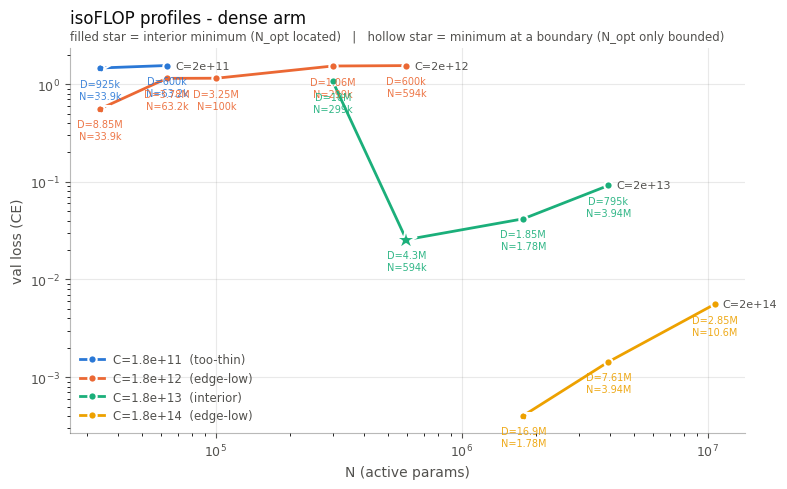

   group          C  best loss        at N  cells
   dense   1.80e+12     0.5595      33,888     10
   dense   1.80e+13     0.0159   1,777,344      8
   dense   1.80e+14     0.0004   1,777,344      4
n_experts=2   1.80e+12     0.5883      50,048      5
n_experts=2   1.80e+13     0.0678     986,368      4
n_experts=2   1.80e+14     0.0011   6,556,672      3
n_experts=8   1.80e+12     0.2072     165,376      5
n_experts=8   1.80e+13     0.0496     986,368      4
n_experts=8   1.80e+14     0.0011   6,556,672      3
n_experts=16   1.80e+12     0.1448      99,840      5
n_experts=16   1.80e+13     0.0166     986,368      4
n_experts=16   1.80e+14     0.0047   2,955,264      3

relative to dense at matched compute (negative = moe better):
  E=2   2e+12: 1.05x  2e+13: 4.27x  2e+14: 2.82x
  E=8   2e+12: 0.37x  2e+13: 3.13x  2e+14: 2.71x
  E=16  2e+12: 0.26x  2e+13: 1.05x  2e+14:11.55x


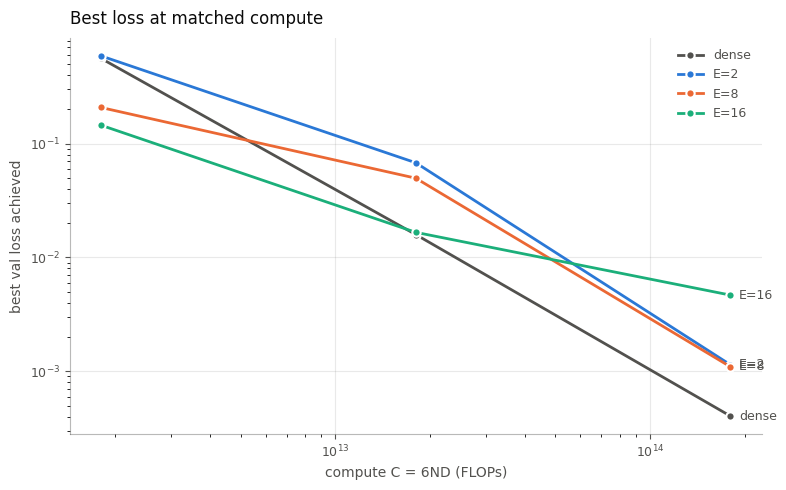

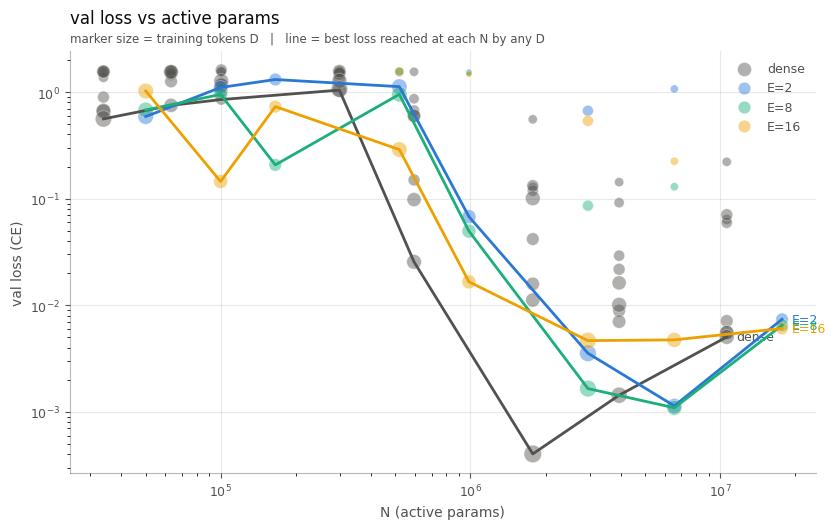

    arm           N  best loss         at D  cells
  dense      33,888    0.55946    8,852,691      9
  dense      63,216    0.74982    3,250,003      8
  dense     100,416    0.84984    1,055,002      8
  dense     298,656    1.04279    3,250,003      9
  dense     594,432    0.02555    4,300,000      8
  dense   1,777,344    0.00040   16,879,118      9
  dense   3,940,608    0.00143    7,613,038      9
  dense  10,634,112    0.00505    4,300,000      8
    E=2      50,048    0.58830    5,994,245      1
    E=2      99,840    1.10338    3,004,807      1
    E=2     165,376    1.30996    1,814,047      1
    E=2     519,168    1.12300    5,778,476      2
    E=2     986,368    0.06781    3,041,461      2
    E=2   2,955,264    0.00355   10,151,377      2
    E=2   6,556,672    0.00114    4,575,491      2
    E=2  17,707,008    0.00740    1,694,244      1
    E=8      50,048    0.67851    5,994,245      1
    E=8      99,840    0.94931    3,004,807      1
    E=8     165,376    0.20724 

In [22]:
# ============================================================================
# isoFLOP profiles — does a compute-optimal N even exist here?
# ============================================================================
# Chinchilla's Approach 2: fix C = 6ND, sweep N, and the loss-vs-N curve is a U.
# The left arm rises because the model is too small; the right arm rises because
# at fixed C a bigger model gets proportionally less data and is undertrained.
# N_opt is the bottom of the U.
#
# Both arms have to rise for a minimum to exist. If capacity always helps and data
# never binds in the range tested, the curve is monotonically DECREASING and the
# "optimum" is just the largest model you ran - a boundary artifact, not a result.
# These functions check which case you are in instead of assuming the U.
#
# NOTE: no MIN_N filter here. The capacity-limited small rungs are exactly the
# left arm of the U - they are excluded from the surface fit, but needed here.

import matplotlib.pyplot as plt
import numpy as np

_INK, _MUTED = "#0b0b0b", "#52514e"
_SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]


def add_compute(rows, kappa=6.0):
    for r in rows:
        r['C'] = kappa * r['N'] * r['D_actual']
    return rows


def isoflop_bands(rows, n_bands=4, tol=0.18, min_points=1):
    """Group cells into log-spaced compute bands.

    C is derived, not chosen: C = 6*N*D_actual for every cell you trained, then
    n_bands log-spaced centres are placed between the min and max observed C and
    each cell joins the centre it is within tol decades of. A grid sweep has no
    exact isoFLOP lines, hence the tolerance. Bands with fewer than 3 distinct N
    min_points controls how thin a band may be. A band with fewer than 3 distinct
    N cannot show an interior minimum by construction, so it is reported as
    'too-thin' rather than 'edge-*' - it carries no verdict either way.

    Each point keeps the D values behind it, since at fixed C the whole story is
    how the budget was split between params and data.
    """
    if not rows:
        return []
    add_compute(rows)
    C = np.array([r['C'] for r in rows])
    centres = np.logspace(np.log10(C.min()) + tol, np.log10(C.max()) - tol, n_bands)
    bands = []
    for c in centres:
        members = [r for r in rows if abs(np.log10(r['C'] / c)) <= tol]
        by_N = {}
        for r in members:                       # several D can land in one band per N
            by_N.setdefault(r['N'], []).append(r)
        pts = []
        for n, rs in sorted(by_N.items()):
            pts.append(dict(N=n,
                            loss=float(np.median([r['val_loss'] for r in rs])),
                            D=float(np.median([r['D_actual'] for r in rs])),
                            C=float(np.median([r['C'] for r in rs])),
                            k=len(rs)))
        if len(pts) >= min_points:
            bands.append(dict(C=float(c), pts=pts, n_cells=len(members)))
    return bands


def classify_band(band):
    """interior = a real optimum; edge-low / edge-high = the minimum is at a boundary
    and N_opt is not measured, only bounded; too-thin = fewer than 3 N, so an
    interior minimum could not be detected even if one existed."""
    Ls = [p['loss'] for p in band['pts']]
    j = int(np.argmin(Ls))
    if len(Ls) < 3:
        kind = 'too-thin'
    elif 0 < j < len(Ls) - 1:
        kind = 'interior'
    else:
        kind = 'edge-low' if j == 0 else 'edge-high'
    return kind, band['pts'][j]['N'], Ls[j]


def isoflop_report(rows, n_bands=4, tol=0.18, detail=True, min_points=1):
    if not rows:
        print("no rows for this arm - nothing to profile.")
        print("  if you wanted the dense control, load it in the fit-range cell:")
        print('      dense_extra, _ = load_rows(tag="dense")')
        return []
    bands = isoflop_bands(rows, n_bands, tol, min_points)
    print(f"{'C':>10} {'cells':>6} {'N pts':>6} {'argmin N':>11} {'L min':>8}  verdict")
    verdicts = []
    for b in bands:
        kind, n_best, l_best = classify_band(b)
        verdicts.append(kind)
        print(f"{b['C']:>10.2e} {b['n_cells']:>6} {len(b['pts']):>6} "
              f"{int(n_best):>11,} {l_best:>8.4f}  {kind}")
    if detail:
        print()
        print("the param/data split behind every point (fixed C, so N up <=> D down):")
        for b in bands:
            print(f"  --- C = {b['C']:.2e} " + "-" * 46)
            print(f"     {'N':>11} {'D':>12} {'D/N':>8} {'actual C':>10} "
                  f"{'loss':>8} {'cells':>6}")
            for p in b['pts']:
                print(f"     {int(p['N']):>11,} {int(p['D']):>12,} "
                      f"{p['D']/p['N']:>8.1f} {p['C']:>10.2e} "
                      f"{p['loss']:>8.4f} {p['k']:>6}")
    print()
    verdicts = [v for v in verdicts if v != 'too-thin']   # thin bands carry no verdict
    n_int = verdicts.count('interior')
    if not verdicts:
        print("every band is too thin to classify - widen tol or add N rungs.")
        return bands
    if n_int == 0:
        print("NO band has an interior minimum.")
        print("  -> loss decreases monotonically in N at fixed compute across the whole")
        print("     range tested. There is no compute-optimal model size here: the best")
        print("     N is always the largest one run. A Chinchilla frontier cannot be")
        print("     measured from this data - not because the fit failed, but because")
        print("     the optimum lies outside the range (or does not exist at this scale).")
    elif n_int < len(verdicts):
        print(f"{n_int}/{len(verdicts)} bands have an interior minimum - partial coverage.")
        print("  -> N_opt is measured only where the verdict is 'interior'; elsewhere it")
        print("     is bounded, not located.")
    else:
        print("All bands have interior minima - isoFLOP profiles are well posed.")
    return bands


def plot_isoflop(rows, n_bands=4, tol=0.18, title="isoFLOP profiles", min_points=1):
    bands = isoflop_bands(rows, n_bands, tol, min_points)
    if not bands:
        print("no bands to plot for this arm.")
        return []
    fig, ax = plt.subplots(figsize=(8, 5))
    def _si(x):
        for div, suf in ((1e9, 'B'), (1e6, 'M'), (1e3, 'k')):
            if x >= div:
                return f"{x/div:.3g}{suf}"
        return f"{x:.0f}"

    for i, b in enumerate(bands):
        Ns = [p['N'] for p in b['pts']]; Ls = [p['loss'] for p in b['pts']]
        col = _SERIES[i % len(_SERIES)]
        kind, n_best, l_best = classify_band(b)
        ax.plot(Ns, Ls, 'o-', color=col, lw=2, markersize=6,
                markeredgecolor='white', markeredgewidth=1.5,
                label=f"C={b['C']:.1e}  ({kind})")
        # hollow marker where the optimum is only bounded, filled where it is located
        ax.plot([n_best], [l_best], marker='*', markersize=16, color=col,
                markeredgecolor='white', markeredgewidth=1.5,
                fillstyle='full' if kind == 'interior' else 'none', zorder=5)
        # per-point split: at fixed C the interesting number is how much data the
        # cell got, so label D directly rather than making the reader compute it
        for p in b['pts']:
            ax.annotate(f"D={_si(p['D'])}\nN={_si(p['N'])}",
                        xy=(p['N'], p['loss']), xytext=(0, -22),
                        textcoords='offset points', ha='center', fontsize=7,
                        linespacing=1.25, color=col, alpha=0.9)
        ax.annotate(f"C={b['C']:.0e}", xy=(Ns[-1], Ls[-1]), xytext=(6, 0),
                    textcoords='offset points', va='center', fontsize=8, color=_MUTED)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel("N (active params)", color=_MUTED, fontsize=10)
    ax.set_ylabel("val loss (CE)", color=_MUTED, fontsize=10)
    ax.set_title(title, color=_INK, fontsize=12, loc='left', pad=18)
    ax.text(0.0, 1.02, "filled star = interior minimum (N_opt located)   |   "
            "hollow star = minimum at a boundary (N_opt only bounded)",
            transform=ax.transAxes, fontsize=8.5, color=_MUTED)
    ax.grid(True, color=_MUTED, alpha=0.12, lw=0.8); ax.set_axisbelow(True)
    for s in ('top', 'right'): ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'): ax.spines[s].set_color(_MUTED); ax.spines[s].set_alpha(0.4)
    ax.tick_params(colors=_MUTED, labelsize=9)
    ax.legend(frameon=False, fontsize=8.5, labelcolor=_MUTED, loc='lower left')
    fig.tight_layout(); plt.show()
    return bands


# ----------------------------------------------------------------------------
# The comparison that survives the noise: best loss at matched compute
# ----------------------------------------------------------------------------
# Locating an argmin under sd~0.5 noise is hopeless; reading off the MINIMUM VALUE
# is far more robust, because it only needs the envelope, not its position.
# This answers "does moe buy anything at matched compute" without estimating a
# single scaling parameter.

def best_loss_vs_compute(rows, group_key='n_experts', n_bands=5, tol=0.18,
                        centres=None, min_cells=2, verbose=True):
    """Best loss reached per arm at each compute budget.

    centres: pass C_TARGETS when the arms came from a designed isoFLOP sweep.
    Deriving centres from the pooled C range instead will misalign them: the
    dense grid spans ~1e11 to 3e14 while a designed moe arm sits on 3 exact
    budgets, so globally-placed bands can miss the moe cells entirely and those
    arms silently collapse to one point.

    min_cells: how many cells an arm needs in a band for its 'best' to mean a
    choice rather than a single run.
    """
    add_compute(rows)
    groups = sorted({r.get(group_key, 0) for r in rows})
    if centres is None:
        C = np.array([r['C'] for r in rows])
        centres = np.logspace(np.log10(C.min()) + tol, np.log10(C.max()) - tol, n_bands)
    centres = np.asarray(centres, dtype=float)

    out, coverage = {}, []
    for g in groups:
        sub = [r for r in rows if r.get(group_key, 0) == g]
        series = []
        for c in centres:
            mem = [r for r in sub if abs(np.log10(r['C'] / c)) <= tol]
            if len(mem) >= min_cells:
                best = min(mem, key=lambda r: r['val_loss'])
                series.append((float(c), best['val_loss'], best['N'], len(mem)))
            else:
                coverage.append((g, float(c), len(mem)))
        out[g] = series

    if verbose and coverage:
        print(f"bands dropped (fewer than {min_cells} cells):")
        for g, c, k in coverage:
            label = 'dense' if g == 0 else f'E={g}'
            print(f"  {label:>7} C={c:.2e}  {k} cell(s)")
        print("  -> pass centres=C_TARGETS if the arms were a designed isoFLOP sweep,\n"
              "     or lower min_cells to plot single-cell bands.")
    return out


def report_best_loss(res, group_key='n_experts'):
    print(f"{'group':>8} {'C':>10} {'best loss':>10} {'at N':>11} {'cells':>6}")
    for g, series in res.items():
        label = 'dense' if g == 0 else f'{group_key}={g}'
        for c, l, n, k in series:
            print(f"{label:>8} {c:>10.2e} {l:>10.4f} {int(n):>11,} {k:>6}")
    base = res.get(0)
    if base and len(res) > 1:
        print()
        print("relative to dense at matched compute (negative = moe better):")
        bmap = {round(np.log10(c), 2): l for c, l, _, _ in base}
        for g, series in res.items():
            if g == 0:
                continue
            deltas = [(c, l / bmap[round(np.log10(c), 2)])
                      for c, l, _, _ in series if round(np.log10(c), 2) in bmap]
            if deltas:
                txt = '  '.join(f"{c:.0e}:{r:>5.2f}x" for c, r in deltas)
                print(f"  E={g:<3} {txt}")


def plot_best_loss(res, group_key='n_experts', title="Best loss at matched compute"):
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, (g, series) in enumerate(sorted(res.items())):
        if not series:
            print(f"  [!] arm {g}: no bands survived - not plotted")
            continue
        if len(series) == 1:
            print(f"  [!] arm {g}: only 1 band - drawn as a point, no trend readable")
        label = 'dense' if g == 0 else f'E={g}'
        col = _MUTED if g == 0 else _SERIES[(i - 1) % len(_SERIES)]
        Cs = [s[0] for s in series]; Ls = [s[1] for s in series]
        ax.plot(Cs, Ls, 'o-', color=col, lw=2, markersize=6,
                markeredgecolor='white', markeredgewidth=1.5, label=label)
        ax.annotate(label, xy=(Cs[-1], Ls[-1]), xytext=(6, 0),
                    textcoords='offset points', va='center', fontsize=9, color=_MUTED)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel("compute C = 6ND (FLOPs)", color=_MUTED, fontsize=10)
    ax.set_ylabel("best val loss achieved", color=_MUTED, fontsize=10)
    ax.set_title(title, color=_INK, fontsize=12, loc='left', pad=10)
    ax.grid(True, color=_MUTED, alpha=0.12, lw=0.8); ax.set_axisbelow(True)
    for s in ('top', 'right'): ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'): ax.spines[s].set_color(_MUTED); ax.spines[s].set_alpha(0.4)
    ax.tick_params(colors=_MUTED, labelsize=9)
    ax.legend(frameon=False, fontsize=9, labelcolor=_MUTED)
    fig.tight_layout(); plt.show()




E_COLORS = {2: "#2a78d6", 4: "#eb6834", 8: "#1baf7a", 16: "#eda100"}
DENSE_COLOR = "#52514e"

# ----------------------------------------------------------------------------
# Loss vs active params — the raw relationship, no compute grouping
# ----------------------------------------------------------------------------
# Every cell plotted against N. Because each cell was trained on a different D,
# marker size encodes the token budget: a big marker low on the chart is a model
# that got lots of data, a small marker is one that was starved. Without that,
# loss-vs-N on an isoFLOP design is misleading - moving right along the x axis
# also means moving DOWN in data, and the two effects are confounded.
#
# The solid line is the per-arm lower envelope: the best loss reached at each N by
# any data budget. That is the closest thing to "how good can a model this size
# get", and it is what the capability threshold shows up in.

def plot_loss_vs_N(rows, group_key='n_experts', envelope=True,
                   title="val loss vs active params"):
    groups = sorted({r.get(group_key, 0) for r in rows})
    fig, ax = plt.subplots(figsize=(8.5, 5.4))

    Ds = np.array([r['D_actual'] for r in rows], dtype=float)
    lo, hi = np.log10(Ds.min()), np.log10(Ds.max())
    def msize(d):                                  # 20 -> 160 pt^2 across the D range
        t = 0.0 if hi <= lo else (np.log10(d) - lo) / (hi - lo)
        return 20 + 140 * t

    for i, g in enumerate(groups):
        sub = sorted((r for r in rows if r.get(group_key, 0) == g),
                     key=lambda r: r['N'])
        if not sub:
            continue
        label = 'dense' if g == 0 else f'E={g}'
        col = DENSE_COLOR if g == 0 else E_COLORS.get(g, _SERIES[i % len(_SERIES)])
        ax.scatter([r['N'] for r in sub], [r['val_loss'] for r in sub],
                   s=[msize(r['D_actual']) for r in sub], color=col, alpha=0.45,
                   linewidths=0.5, edgecolors='white', zorder=2, label=label)
        if envelope:
            best = {}
            for r in sub:
                if r['N'] not in best or r['val_loss'] < best[r['N']]:
                    best[r['N']] = r['val_loss']
            xs = sorted(best)
            ax.plot(xs, [best[x] for x in xs], color=col, lw=2, zorder=3)
            ax.annotate(label, xy=(xs[-1], best[xs[-1]]), xytext=(7, 0),
                        textcoords='offset points', va='center', fontsize=9,
                        color=col)

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel("N (active params)", color=_MUTED, fontsize=10)
    ax.set_ylabel("val loss (CE)", color=_MUTED, fontsize=10)
    ax.set_title(title, color=_INK, fontsize=12, loc='left', pad=20)
    ax.text(0.0, 1.02, "marker size = training tokens D   |   line = best loss "
            "reached at each N by any D", transform=ax.transAxes,
            fontsize=8.5, color=_MUTED)
    ax.grid(True, color=_MUTED, alpha=0.12, lw=0.8); ax.set_axisbelow(True)
    for s in ('top', 'right'): ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'): ax.spines[s].set_color(_MUTED); ax.spines[s].set_alpha(0.4)
    ax.tick_params(colors=_MUTED, labelsize=9)
    ax.legend(frameon=False, fontsize=9, labelcolor=_MUTED, loc='best')
    fig.tight_layout(); plt.show()

    print(f"{'arm':>7} {'N':>11} {'best loss':>10} {'at D':>12} {'cells':>6}")
    for g in groups:
        sub = [r for r in rows if r.get(group_key, 0) == g]
        for N in sorted({r['N'] for r in sub}):
            at = [r for r in sub if r['N'] == N]
            b = min(at, key=lambda r: r['val_loss'])
            label = 'dense' if g == 0 else f'E={g}'
            print(f"{label:>7} {int(N):>11,} {b['val_loss']:>10.5f} "
                  f"{int(b['D_actual']):>12,} {len(at):>6}")

# --- apply -----------------------------------------------------------------
# rows, not fit_rows: the isoFLOP profile needs the capacity-limited small rungs
# as the left arm of the U.
bands = isoflop_report(rows_where(all_rows, 0))
plot_isoflop(rows_where(all_rows, 0), title="isoFLOP profiles - dense arm")

# centres = the budgets the moe arms were actually designed at. Without this the
# bands are placed across the pooled dense+moe C range and the moe arms lose most
# of their points.
res = best_loss_vs_compute(all_rows, centres=C_TARGETS)
report_best_loss(res)
plot_best_loss(res)

plot_loss_vs_N(all_rows)


In [ ]:
# ============================================================================
# OPTIONAL: top up an existing grid sweep instead of running an isoFLOP design
# ============================================================================
# Only needed if `rows` came from the legacy grid (section 4). A fresh isoFLOP
# sweep needs nothing here - every cell already sits on a band centre.
#
# plans = {E: plan_infill(rows, C_TARGETS, MODEL_LADDER, POOL_TOKENS,
#                         cfg=base_cfg.replace(num_experts=E),
#                         min_D=DATA_LADDER[0] * 0.5) for E in E_LADDER}
# for E, plan in plans.items():
#     run_infill(base_cfg.replace(num_experts=E), plan, rows, _tt, _tm, _vt, _vm)
# ROWS_PATH = save_rows(rows, D_ceiling, "moe")


In [26]:
# ============================================================================
# 5. Fit L(N,D) = E + A/N^alpha + B/D^beta  (Huber on log-loss, multi-restart)
# ============================================================================
from scipy.special import logsumexp

# _predict_logL is plain numpy, deliberately.
#
# It used to be a jax function, which caused two problems. least_squares has no
# analytic jacobian here so it finite-differences: under jax's DEFAULT float32 the
# nudge fell below float32 resolution for the amplitude parameters, their gradient
# came back exactly zero, and least_squares returned them at their random starting
# values - the dense run once reported A=0.5517, B=135, which were restart #3's
# starting draws, not a fit. And it was slow: ~2,400 residual evaluations per
# fit_surface call at ~9.5 ms each of jax dispatch, for 32 numbers of arithmetic.
#
# numpy is float64 natively (trap gone) and ~5x faster. No autodiff is used
# anywhere in this fitter, so jax was buying nothing. Same functional form, same
# huber delta, same restarts, same seed - results match to 5 significant figures.


def _predict_logL(params, N, D):
    a, b, e, alpha, beta = params
    terms = np.stack([
        a - alpha * np.log(N),
        b - beta  * np.log(D),
        np.full_like(N, e),
    ], axis=0)
    return logsumexp(terms, axis=0)


def fit_surface(rows, huber_delta=1e-3, n_restarts=30, seed=0):
    N = np.array([r['N'] for r in rows], dtype=np.float64)
    D = np.array([r['D_actual'] for r in rows], dtype=np.float64)
    logL = np.log(np.array([r['val_loss'] for r in rows], dtype=np.float64))

    def resid(p):
        return _predict_logL(p, N, D) - logL

    rng = np.random.default_rng(seed)
    best = None
    for _ in range(n_restarts):
        p0 = np.array([rng.uniform(-2, 6),      # log A
                       rng.uniform(-2, 6),      # log B
                       rng.uniform(-2, 0),      # log E
                       rng.uniform(0.1, 0.9),   # alpha
                       rng.uniform(0.1, 0.9)])  # beta
        try:
            r = least_squares(resid, p0, loss='huber',
                              f_scale=huber_delta, max_nfev=10000)
        except Exception:
            continue
        if best is None or r.cost < best.cost:
            best = r

    if best is None:
        raise RuntimeError("all restarts failed")
    a, b, e, alpha, beta = best.x
    return dict(A=float(np.exp(a)), B=float(np.exp(b)), E=float(np.exp(e)),
                alpha=float(alpha), beta=float(beta),
                raw=best.x, cost=float(best.cost))


def bootstrap_fit(rows, n_boot=200, seed=0, progress_every=10):
    """Percentile CIs by resampling cells with replacement.

    Cost is n_boot full re-fits, so this dominates the analysis. progress_every
    prints an ETA - without it a slow run is indistinguishable from a hung one,
    and how long it takes depends on how noisy the data is (noisy residuals make
    least_squares take many more iterations per restart).
    """
    import time
    rng = np.random.default_rng(seed)
    keys = ['A', 'B', 'E', 'alpha', 'beta']
    samples = {k: [] for k in keys}
    extra = {'p': [], 'q': []}
    n = len(rows)
    t0 = time.time()
    for i_boot in range(n_boot):
        if progress_every and i_boot and i_boot % progress_every == 0:
            el = time.time() - t0
            eta = el / i_boot * (n_boot - i_boot)
            print(f"    bootstrap {i_boot:>4}/{n_boot}  elapsed {el/60:>5.1f} min  "
                  f"eta {eta/60:>5.1f} min", flush=True)
        sub = [rows[i] for i in rng.integers(0, n, n)]
        try:
            f = fit_surface(sub, n_restarts=8, seed=int(rng.integers(1e9)))
        except Exception:
            continue
        for k in keys:
            samples[k].append(f[k])
        s = f['alpha'] + f['beta']
        extra['p'].append(f['beta'] / s)
        extra['q'].append(f['alpha'] / s)

    def ci(arr):
        arr = np.array(arr)
        return dict(median=float(np.median(arr)),
                    lo=float(np.percentile(arr, 2.5)),
                    hi=float(np.percentile(arr, 97.5)))
    out = {k: ci(samples[k]) for k in keys}
    out['p'] = ci(extra['p'])
    out['q'] = ci(extra['q'])
    return out

In [28]:
# ============================================================================
# 6. Part 2: impose compute analytically. D = C/(6N), minimize over N.
# ============================================================================
def derive_frontier(fit, C_grid=None, D_ceiling=None):
    """Closed form from stationarity of A/N^alpha + B/(C/6N)^beta:
       N_opt = [ (alpha*A)/(beta*B) * (C/6)^beta ]^(1/(alpha+beta))
       so N_opt ~ C^p, D_opt ~ C^q with p=beta/(alpha+beta), q=alpha/(alpha+beta)."""
    A, B, alpha, beta = fit['A'], fit['B'], fit['alpha'], fit['beta']
    p = beta / (alpha + beta)
    q = alpha / (alpha + beta)

    if C_grid is None:
        C_grid = np.logspace(11, 18, 50)

    N_opt = ((alpha * A) / (beta * B) * (C_grid / 6.0) ** beta) ** (1.0 / (alpha + beta))
    D_opt = C_grid / (6.0 * N_opt)
    L_opt = fit['E'] + A / N_opt ** alpha + B / D_opt ** beta

    grounded = C_star = None
    if D_ceiling is not None:
        grounded = D_opt <= D_ceiling
        C_star = float(C_grid[grounded].max()) if grounded.any() else None

    return dict(C=C_grid, N_opt=N_opt, D_opt=D_opt, L_opt=L_opt,
                p=p, q=q, grounded=grounded, C_max_grounded=C_star)

In [29]:

# ============================================================================
# 7. Report
# ============================================================================
def report(fit, ci, fr):
    print("\n=== fitted surface L(N,D) = E + A/N^alpha + B/D^beta ===")
    for k in ['A', 'B', 'E', 'alpha', 'beta']:
        c = ci[k]
        print(f"  {k:>5} = {fit[k]:.4g}   95% CI [{c['lo']:.4g}, {c['hi']:.4g}]")
    print("\n=== compute-optimal frontier ===")
    print(f"  N_opt ~ C^{fr['p']:.4f}   95% CI [{ci['p']['lo']:.4f}, {ci['p']['hi']:.4f}]")
    print(f"  D_opt ~ C^{fr['q']:.4f}   95% CI [{ci['q']['lo']:.4f}, {ci['q']['hi']:.4f}]")
    if fr['C_max_grounded'] is not None:
        print(f"\n  data ceiling reached at C = {fr['C_max_grounded']:.3g} FLOPs")
        print("  beyond this the frontier extrapolates past the dataset "
              "(data-constrained regime; cf. Muennighoff et al. 2023)")

In [ ]:
# dense reference arm (E=0). the moe slices are fitted per-E in section 9 below.
# the dense control. With E_LADDER = [4, 8] this notebook trains no E=0 cells, so
# load them from the dense notebook's saved sweep instead of refitting nothing.
dense_rows = rows_where(fit_rows, 0)
if not dense_rows:
    print("no E=0 rows in this sweep - load them with:")
    print('    _d, _ = load_rows(tag="dense"); rows += _d')
    print("  then re-run the fit-range cell. Skipping the dense reference for now.")
fit = fit_surface(dense_rows) if dense_rows else None
ci  = bootstrap_fit(dense_rows, n_boot=200) if dense_rows else None
if dense_rows:
    fr  = derive_frontier(fit, D_ceiling=D_ceiling)
    report(fit, ci, fr)

In [ ]:
# ============================================================================
# 8. Plot the frontier: empirical compute-optimal points vs the fitted power law
# ============================================================================
import matplotlib.pyplot as plt

INK, MUTED = "#0b0b0b", "#52514e"
MEASURED, FITLINE = "#2a78d6", "#eb6834"   # categorical slots 1 and 2


def frontier_points(rows, n_bins=6):
    """Empirical compute-optimal points. Each measured cell sits at its own
    C = 6ND, so bin the cells in log-C and take the lowest-loss cell per bin.
    A bin is only a real minimum if several model sizes land in it - n_cells
    is returned so thin bins can be judged (or dropped) rather than trusted."""
    N = np.array([r['N'] for r in rows], dtype=np.float64)
    D = np.array([r['D_actual'] for r in rows], dtype=np.float64)
    L = np.array([r['val_loss'] for r in rows], dtype=np.float64)
    C = 6.0 * N * D

    edges = np.logspace(np.log10(C.min()), np.log10(C.max()) + 1e-9, n_bins + 1)
    which = np.clip(np.digitize(C, edges) - 1, 0, n_bins - 1)

    pts = []
    for b in range(n_bins):
        sel = np.flatnonzero(which == b)
        if sel.size == 0:
            continue
        j = sel[np.argmin(L[sel])]
        pts.append(dict(C=C[j], N=N[j], D=D[j], L=L[j], n_cells=int(sel.size)))
    return pts, dict(C=C, N=N, D=D, L=L)


def plot_frontier(rows, fit, fr, n_bins=6):
    pts, cloud = frontier_points(rows, n_bins)
    c_lo, c_hi = cloud['C'].min(), cloud['C'].max()

    # the fit is only grounded where we actually measured - split the curve there
    inside = (fr['C'] >= c_lo) & (fr['C'] <= c_hi)
    panels = [
        ("N_opt", 'N', 'N_opt', f"N ~ C^{fr['p']:.3f}", "parameters"),
        ("D_opt", 'D', 'D_opt', f"D ~ C^{fr['q']:.3f}", "supervised tokens"),
        ("L_opt", 'L', 'L_opt', "fitted L(N,D) along the frontier", "val loss (CE)"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
    for ax, (_, cloud_key, fit_key, fitlabel, ylab) in zip(axes, panels):
        # every measured cell, recessive - context for how the minima were found
        ax.scatter(cloud['C'], cloud[cloud_key], s=14, color=MEASURED, alpha=0.22,
                   linewidths=0, zorder=2, label="all measured cells")

        # fitted frontier: solid where grounded, dashed where extrapolated
        ax.plot(fr['C'][inside], fr[fit_key][inside], color=FITLINE, lw=2,
                zorder=3, label=fitlabel)
        ax.plot(fr['C'][~inside], fr[fit_key][~inside], color=FITLINE, lw=2,
                ls=(0, (4, 3)), alpha=0.55, zorder=3, label="extrapolated")

        # empirical minima - white ring so they read on top of the cloud
        ax.scatter([p['C'] for p in pts], [p[cloud_key] for p in pts], s=64,
                   color=MEASURED, edgecolor="white", linewidth=2, zorder=4,
                   label="per-budget best cell")

        ax.set_xscale('log')
        if cloud_key != 'L':
            ax.set_yscale('log')
        # keep the view on the measured range - fr's default C_grid runs to 1e18
        # and would otherwise squeeze every measured point into the left edge
        ax.set_xlim(c_lo / 3, c_hi * 30)
        ax.set_xlabel("compute C (FLOPs)", color=MUTED, fontsize=10)
        ax.set_ylabel(ylab, color=MUTED, fontsize=10)
        ax.grid(True, which='major', color=MUTED, alpha=0.12, lw=0.8)
        ax.set_axisbelow(True)
        for side in ('top', 'right'):
            ax.spines[side].set_visible(False)
        for side in ('left', 'bottom'):
            ax.spines[side].set_color(MUTED)
            ax.spines[side].set_alpha(0.4)
        ax.tick_params(colors=MUTED, labelsize=9)

        # data ceiling: past here the frontier wants more data than the pool has
        if fr.get('C_max_grounded'):
            ax.axvline(fr['C_max_grounded'], color=MUTED, lw=1,
                       ls=(0, (2, 3)), alpha=0.6, zorder=1)

    axes[0].set_title(f"compute-optimal frontier  (E={fit['E']:.3f}, "
                      f"alpha={fit['alpha']:.3f}, beta={fit['beta']:.3f})",
                      color=INK, fontsize=12, loc='left', pad=12)
    axes[0].legend(frameon=False, fontsize=9, labelcolor=MUTED, loc='best')

    fig.tight_layout()
    plt.show()

    print(f"{'C':>10} {'N':>11} {'D':>11} {'val_loss':>9} {'cells in bin':>13}")
    for p in pts:
        print(f"{p['C']:>10.2e} {p['N']:>11,.0f} {p['D']:>11,.0f} "
              f"{p['L']:>9.4f} {p['n_cells']:>13}")
    if fr.get('C_max_grounded'):
        print(f"\ndotted vline = data ceiling at C={fr['C_max_grounded']:.3g} "
              "(frontier beyond it needs more data than the pool holds)")


# dense reference arm; the per-E moe frontiers are plotted in section 11
plot_frontier(dense_rows, fit, fr)

In [31]:
def diagnose_bootstrap(rows, n_boot=200, seed=0):
    rng = np.random.default_rng(seed)
    a_s, b_s, e_s = [], [], []
    n = len(rows)
    for _ in range(n_boot):
        sub = [rows[i] for i in rng.integers(0, n, n)]
        try:
            f = fit_surface(sub, n_restarts=8, seed=int(rng.integers(1e9)))
        except Exception:
            continue
        a_s.append(f['alpha']); b_s.append(f['beta']); e_s.append(f['E'])
    a_s, b_s, e_s = map(np.array, (a_s, b_s, e_s))
    for name, arr in [('alpha', a_s), ('beta', b_s)]:
        print(f"{name}: median {np.median(arr):.3f}  "
              f"IQR [{np.percentile(arr,25):.3f}, {np.percentile(arr,75):.3f}]  "
              f"frac > 1.0: {(arr > 1.0).mean():.3f}")
    print(f"corr(alpha, log E) = {np.corrcoef(a_s, np.log(e_s))[0,1]:.3f}")
    return a_s, b_s, e_s

diagnose_bootstrap(dense_rows)

alpha: median 0.678  IQR [0.502, 0.870]  frac > 1.0: 0.208
beta: median 0.509  IQR [0.368, 0.686]  frac > 1.0: 0.066
corr(alpha, log E) = 0.069


(array([ 0.39165282,  0.49073114,  0.84525637,  0.2798987 ,  0.66969239,
         0.74236049,  4.80755757,  0.50784443,  0.82499613,  5.70514305,
         0.73954958,  2.72119493,  0.69684261,  0.32847263,  0.4014916 ,
         0.37812599,  0.77776391,  0.89750646,  0.74628067,  0.71326075,
         0.57259626,  0.87714356,  0.7992693 ,  0.76564478,  0.55822344,
         0.22494558,  0.53950164,  0.16333883,  0.35092803,  0.35372145,
         0.61249263,  0.38945382,  0.76889691,  0.55542824,  0.52227936,
         0.41640593,  0.75849392,  0.69827374,  0.88315844,  0.5522495 ,
         0.47742872,  7.15426099,  0.52698735,  0.54508528,  0.75327946,
         3.14668503,  5.38486106,  0.28704215,  0.81642963,  0.6848769 ,
         4.51306199,  0.37797413,  0.72264052,  0.59203074,  5.42771508,
         0.69833226,  0.40311345,  0.80396099,  0.89861665,  0.87191872,
         0.62545308,  0.6326403 ,  0.4226541 ,  0.8897161 ,  0.68140421,
         5.45028753,  0.27846932,  0.6384528 ,  0.7

In [ ]:
# ============================================================================
# 9. Per-E fits — same fitter, called once per slice
# ============================================================================
# fit_surface is unchanged: same log-sum-exp parameterization, same huber delta,
# same multi-restart grid. Only the row subset differs.
#
# What to look for in the table:
#   alpha, beta, B   roughly flat across E   -> the surface shape is E-invariant
#   E_irr (c)        near zero everywhere    -> no spurious floor
#   A                declining with E        -> the moe effect lives entirely in A
# E_irr is the irreducible term of L = E_irr + A/N^alpha + B/D^beta. It is named
# 'E' inside fit_surface; renamed here so it cannot be confused with num_experts.

# an E slice can be emptied by the fit-range filter; a 5-parameter surface needs
# more than a handful of points, so drop slices that no longer support one
_usable = [E for E in E_LADDER if len(rows_where(fit_rows, E)) >= 6]
for E in E_LADDER:
    if E not in _usable:
        print(f"[!] E={E}: only {len(rows_where(fit_rows, E))} cells survive the "
              f"fit range - skipped")
E_LADDER = _usable

fits = {E: fit_surface(rows_where(fit_rows, E)) for E in E_LADDER}
cis  = {E: bootstrap_fit(rows_where(fit_rows, E), n_boot=200) for E in E_LADDER}


def fit_table(fits, cis, e_ladder=E_LADDER):
    print(f"{'E':>4} {'n':>4} {'A':>12} {'B':>12} {'E_irr (c)':>12} "
          f"{'alpha':>8} {'beta':>8}")
    for E in e_ladder:
        f, c = fits[E], cis[E]
        n = len(rows_where(fit_rows, E))
        print(f"{E:>4} {n:>4} {f['A']:>12.4g} {f['B']:>12.4g} {f['E']:>12.4g} "
              f"{f['alpha']:>8.4f} {f['beta']:>8.4f}")
    print()
    print("95% CI (bootstrap):")
    for E in e_ladder:
        c = cis[E]
        print(f"  E={E:<3} A [{c['A']['lo']:.4g}, {c['A']['hi']:.4g}]   "
              f"alpha [{c['alpha']['lo']:.3f}, {c['alpha']['hi']:.3f}]   "
              f"beta [{c['beta']['lo']:.3f}, {c['beta']['hi']:.3f}]")

    # the three flatness checks, stated numerically rather than eyeballed
    print()
    moe_E = [E for E in e_ladder if E > 0]
    for key in ('alpha', 'beta', 'B'):
        vals = np.array([fits[E][key] for E in moe_E])
        spread = vals.max() / max(vals.min(), 1e-12)
        flag = "flat" if spread < 1.5 else "NOT flat - pooling is unjustified"
        print(f"  {key:>6}: {vals.round(4)}  max/min={spread:.2f}  {flag}")
    A_vals = np.array([fits[E]['A'] for E in moe_E])
    mono = np.all(np.diff(A_vals) < 0)
    print(f"  {'A':>6}: {A_vals.round(4)}  "
          f"{'monotonically declining in E' if mono else 'NOT monotonic - second stage is not meaningful'}")
    c_vals = np.array([fits[E]['E'] for E in e_ladder])
    print(f"  {'E_irr':>6}: {c_vals.round(4)}  "
          f"{'near zero' if np.all(c_vals < 0.05) else 'nonzero - a floor is being absorbed here'}")


fit_table(fits, cis)

In [ ]:
# ============================================================================
# 10. Second stage: A(E) = a + g / E^gamma
# ============================================================================
# Run this ONLY if section 9 showed alpha/beta/B flat and A declining. Four points
# and three parameters is thin - the fit is reported with error bars, not as a law.

def fit_A_of_E(fits, cis, e_ladder=None, n_restarts=200, seed=0):
    """1-D least squares of A(E) = a + g/E^gamma over the moe slices.

    Weighted by each A's bootstrap CI width, so a slice the first-stage fitter was
    unsure about does not drag the curve. Returns the fit plus the diagnostics
    needed to decide whether to believe it."""
    e_ladder = e_ladder or [E for E in fits if E > 0]
    Evals = np.array(sorted(e_ladder), dtype=np.float64)
    A = np.array([fits[int(E)]['A'] for E in Evals], dtype=np.float64)
    # CI half-width as sigma; floor it so a degenerate CI cannot dominate
    sigma = np.array([max((cis[int(E)]['A']['hi'] - cis[int(E)]['A']['lo']) / 2.0,
                          1e-3 * abs(fits[int(E)]['A'])) for E in Evals])

    n_pts, n_par = len(Evals), 3
    def resid(p):
        a, g, gamma = p
        return (a + g / Evals ** gamma - A) / sigma

    rng = np.random.default_rng(seed)
    best = None
    for _ in range(n_restarts):
        p0 = np.array([rng.uniform(0, max(A.max(), 1e-6)),
                       rng.uniform(0, 5 * max(A.max(), 1e-6)),
                       rng.uniform(0.05, 2.0)])
        try:
            r = least_squares(resid, p0, max_nfev=10000)
        except Exception:
            continue
        if best is None or r.cost < best.cost:
            best = r
    if best is None:
        raise RuntimeError("all restarts failed")

    a, g, gamma = best.x
    pred = a + g / Evals ** gamma
    ss_res = float(np.sum((A - pred) ** 2))
    ss_tot = float(np.sum((A - A.mean()) ** 2))
    dof = n_pts - n_par

    # parameter sigmas from the jacobian; only meaningful when dof > 0
    perr = np.full(3, np.nan)
    if dof > 0:
        try:
            _, s, VT = np.linalg.svd(best.jac, full_matrices=False)
            s = s[s > 1e-12]
            cov = (VT[:len(s)].T / s**2) @ VT[:len(s)]
            perr = np.sqrt(np.diag(cov) * (2 * best.cost / dof))
        except Exception:
            pass

    return dict(a=float(a), g=float(g), gamma=float(gamma),
                perr=perr, E=Evals, A=A, sigma=sigma, pred=pred,
                r2=float(1 - ss_res / ss_tot) if ss_tot > 0 else float('nan'),
                dof=dof, n_points=n_pts)


def report_A_of_E(af):
    lo_dof = af['dof'] <= 0
    print("=== second stage: A(E) = a + g / E^gamma ===")
    print(f"  points: {af['n_points']}   parameters: 3   dof: {af['dof']}")
    if lo_dof:
        print("  [!] dof <= 0 - the curve interpolates the points and the error bars are\n"
              "      undefined. Add E=32 before quoting gamma as anything.")
    names = ('a', 'g', 'gamma')
    for i, nm in enumerate(names):
        e = af['perr'][i]
        pm = f" +/- {e:.4g}" if np.isfinite(e) else "  (undefined)"
        print(f"  {nm:>6} = {af[nm]:.6g}{pm}")
    print(f"  R^2 = {af['r2']:.4f}")
    print()
    print(f"  {'E':>4} {'A fitted':>12} {'A(E) pred':>12} {'resid':>10} {'sigma':>10}")
    for E, a_i, p_i, s_i in zip(af['E'], af['A'], af['pred'], af['sigma']):
        print(f"  {int(E):>4} {a_i:>12.5g} {p_i:>12.5g} {a_i - p_i:>10.3g} {s_i:>10.3g}")
    print()
    print(f"  asymptote a = {af['a']:.5g}: the A that infinite experts would buy.")
    print("  Treat gamma as indicative. With 4 points it is not separately identified\n"
          "  from g - report the curve, not the exponent.")


def plot_A_of_E(af):
    fig, ax = plt.subplots(figsize=(6, 4.2))
    grid = np.logspace(np.log10(af['E'].min()), np.log10(af['E'].max()), 200)
    ax.plot(grid, af['a'] + af['g'] / grid ** af['gamma'], color=FITLINE, lw=2,
            zorder=2, label=f"a + g/E^{af['gamma']:.2f}")
    ax.axhline(af['a'], color=MUTED, lw=1, ls=(0, (2, 3)), alpha=0.7, zorder=1)
    ax.errorbar(af['E'], af['A'], yerr=af['sigma'], fmt='o', color=MEASURED,
                ecolor=MEASURED, elinewidth=1.5, capsize=4, markersize=7,
                markeredgecolor='white', markeredgewidth=1.5, zorder=3,
                label="per-E fitted A (95% CI)")
    ax.set_xscale('log'); ax.set_xticks(af['E'])
    ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    # E is a discrete ladder - suppress the log decade minor ticks between the points
    ax.xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
    ax.xaxis.set_minor_locator(matplotlib.ticker.NullLocator())
    ax.set_xlabel("num_experts E", color=MUTED, fontsize=10)
    ax.set_ylabel("A", color=MUTED, fontsize=10)
    ax.set_title(f"A declines with E   (asymptote a={af['a']:.4g}, R^2={af['r2']:.3f})",
                 color=INK, fontsize=11, loc='left', pad=10)
    ax.grid(True, color=MUTED, alpha=0.12, lw=0.8); ax.set_axisbelow(True)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(MUTED); ax.spines[s].set_alpha(0.4)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.legend(frameon=False, fontsize=9, labelcolor=MUTED)
    fig.tight_layout(); plt.show()


import matplotlib, matplotlib.ticker
A_fit = fit_A_of_E(fits, cis)
report_A_of_E(A_fit)
plot_A_of_E(A_fit)

In [ ]:
# ============================================================================
# 11. The optimum, with A(E) in place of the scalar A
# ============================================================================
#   N_opt(C, E) = [ alpha * A(E) * C^beta / (beta * B * kappa^beta) ]^(1/(alpha+beta))
#   D_opt(C, E) = C / (kappa * N_opt)
#
# kappa = 6 as in the dense case: still a good approximation for moe flops once N
# is ACTIVE params, since only top_k experts run per token.
#
# The exponent p = beta/(alpha+beta) does not depend on A, so every E line has the
# SAME slope in log-log as dense. Only the intercept moves. That is the whole moe
# effect in one sentence, and it is the sentence worth putting in the writeup.

KAPPA = 6.0


def pooled_shape(fits, e_ladder=None):
    """alpha, beta, B shared across E (section 9 is what licenses this). Median is
    used rather than the mean so one bad slice cannot drag the pool."""
    e_ladder = e_ladder or [E for E in fits if E > 0]
    out = {k: float(np.median([fits[E][k] for E in e_ladder]))
           for k in ('alpha', 'beta', 'B', 'E')}
    out['spread'] = {k: (float(np.min([fits[E][k] for E in e_ladder])),
                         float(np.max([fits[E][k] for E in e_ladder])))
                     for k in ('alpha', 'beta', 'B')}
    return out


def A_of_E(af, E):
    return af['a'] + af['g'] / np.asarray(E, dtype=np.float64) ** af['gamma']


def frontier_for_A(A_val, shape, C_grid, kappa=KAPPA, D_ceiling=None):
    """Closed form with A supplied explicitly, so it serves both the dense arm
    (A from its own fit) and each moe E (A from A(E))."""
    alpha, beta, B = shape['alpha'], shape['beta'], shape['B']
    p = beta / (alpha + beta)
    q = alpha / (alpha + beta)

    N_opt = (alpha * A_val * C_grid ** beta / (beta * B * kappa ** beta)) ** (1.0 / (alpha + beta))
    D_opt = C_grid / (kappa * N_opt)
    L_opt = shape['E'] + A_val / N_opt ** alpha + B / D_opt ** beta

    C_star = None
    if D_ceiling is not None:
        # first C at which the frontier wants more tokens than the pool holds
        over = D_opt > D_ceiling
        if over.all():
            C_star = float(C_grid[0])   # already over the ceiling at the left edge
        elif over.any():
            C_star = float(C_grid[over][0])

    return dict(C=C_grid, N_opt=N_opt, D_opt=D_opt, L_opt=L_opt,
                ratio=D_opt / N_opt, p=p, q=q, C_cross=C_star, A=float(A_val))


def build_frontiers(fits, A_fit, D_ceiling, C_grid=None, e_ladder=None):
    e_ladder = e_ladder or [E for E in fits if E > 0]
    shape = pooled_shape(fits, e_ladder)
    if C_grid is None:
        C_grid = np.logspace(11, 18, 400)

    out = {}
    # dense reference uses its own fitted A and its own shape - it is the control,
    # not a point on the A(E) curve
    dense_shape = {k: fits[0][k] for k in ('alpha', 'beta', 'B', 'E')}
    out[0] = frontier_for_A(fits[0]['A'], dense_shape, C_grid, D_ceiling=D_ceiling)
    for E in e_ladder:
        out[E] = frontier_for_A(float(A_of_E(A_fit, E)), shape, C_grid,
                                D_ceiling=D_ceiling)
    return out, shape


def report_frontiers(frs, shape, A_fit, D_ceiling, e_ladder=None):
    e_ladder = e_ladder or [E for E in frs if E > 0]
    print("=== pooled surface shape (moe slices) ===")
    for k in ('alpha', 'beta', 'B'):
        lo, hi = shape['spread'][k]
        print(f"  {k:>6} = {shape[k]:.4f}   across-E range [{lo:.4g}, {hi:.4g}]")
    print(f"\n  p = beta/(alpha+beta) = {frs[e_ladder[0]]['p']:.4f}  "
          f"(N_opt ~ C^p, identical for every E by construction)")
    print(f"  q = alpha/(alpha+beta) = {frs[e_ladder[0]]['q']:.4f}  (D_opt ~ C^q)")
    print(f"\n  dense p = {frs[0]['p']:.4f} from its own fit - if this differs much from\n"
          f"  the moe p, the 'same slope, different intercept' claim does not hold.")

    print(f"\n=== tokens per active param, and where each line leaves the data ===")
    print(f"  D ceiling = {D_ceiling:,} supervised tokens")
    print(f"  {'E':>5} {'A':>12} {'D/N at C=1e13':>15} {'C at ceiling':>14}")
    for E in [0] + list(e_ladder):
        fr = frs[E]
        j = int(np.argmin(np.abs(fr['C'] - 1e13)))
        cross = f"{fr['C_cross']:.3g}" if fr['C_cross'] else "not reached"
        label = "dense" if E == 0 else f"E={E}"
        print(f"  {label:>5} {fr['A']:>12.4g} {fr['ratio'][j]:>15.2f} {cross:>14}")

In [ ]:
# ============================================================================
# 12. The plot: tokens per active param (D_opt / N_opt) vs compute, one line per E
# ============================================================================
# If the theory holds, higher E sits ABOVE dense: more tokens per active param.
# Each line is solid only up to the point where its D_opt crosses the data ceiling;
# past that marker it is extrapolation that cannot be validated here, and it is
# drawn dashed and said out loud rather than quietly continued.

# categorical slots 1-4 for the E lines (validated as a set), neutral for dense.
E_COLORS = {2: "#2a78d6", 4: "#eb6834", 8: "#1baf7a", 16: "#eda100"}
DENSE_COLOR = "#52514e"


def plot_tokens_per_param(frs, D_ceiling, e_ladder=None, C_lo=1e11, C_hi=1e17):
    e_ladder = e_ladder or sorted(E for E in frs if E > 0)
    fig, ax = plt.subplots(figsize=(9.5, 5.6))

    def draw(E, fr, color, label, lw, z):
        C, ratio = fr['C'], fr['ratio']
        vis = (C >= C_lo) & (C <= C_hi)
        cross = fr['C_cross']
        grounded = vis & (C <= cross) if cross else vis

        ax.plot(C[grounded], ratio[grounded], color=color, lw=lw, zorder=z, label=label)
        if cross is not None:
            beyond = vis & (C >= cross)
            ax.plot(C[beyond], ratio[beyond], color=color, lw=lw, ls=(0, (4, 3)),
                    alpha=0.5, zorder=z)
            j = int(np.argmin(np.abs(C - cross)))
            # marker = the last compute budget this dataset can actually validate
            ax.plot([cross], [ratio[j]], marker='o', markersize=8, color=color,
                    markeredgecolor='white', markeredgewidth=2, zorder=z + 1)

        # remember the right-edge value; labels are placed after de-collision below
        k = np.flatnonzero(vis)[-1]
        label_anchors.append((ratio[k], label))

    label_anchors = []
    draw(0, frs[0], DENSE_COLOR, "dense", 2.0, 3)
    for E in e_ladder:
        draw(E, frs[E], E_COLORS.get(E, MEASURED), f"E={E}", 2.0, 4)

    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlim(C_lo, C_hi * 3)
    ax.set_xlabel("compute C (FLOPs)", color=MUTED, fontsize=10)
    ax.set_ylabel("D_opt / N_opt  (supervised tokens per active param)",
                  color=MUTED, fontsize=10)
    ax.set_title("Compute-optimal tokens per active parameter",
                 color=INK, fontsize=12, loc='left', pad=26)
    ax.text(0.0, 1.02, "solid = grounded in measured data   |   dashed = past the "
            f"{D_ceiling/1e6:.1f}M-token ceiling, unvalidated",
            transform=ax.transAxes, fontsize=9, color=MUTED)

    # direct labels at the right edge - required relief for the low-contrast slots,
    # and it keeps identity off color alone. Lines converge at high C, so nudge the
    # labels apart in axes space rather than letting them overprint.
    lo, hi = np.log10(ax.get_ylim())
    placed = sorted(((np.log10(v) - lo) / (hi - lo), t) for v, t in label_anchors)
    MIN_GAP = 0.045
    for i in range(1, len(placed)):
        if placed[i][0] - placed[i - 1][0] < MIN_GAP:
            placed[i] = (placed[i - 1][0] + MIN_GAP, placed[i][1])
    for frac, text in placed:
        ax.annotate(text, xy=(1.005, frac), xycoords='axes fraction',
                    va='center', fontsize=9, color=MUTED, annotation_clip=False)
    ax.grid(True, which='major', color=MUTED, alpha=0.12, lw=0.8)
    ax.set_axisbelow(True)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(MUTED); ax.spines[s].set_alpha(0.4)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.legend(frameon=False, fontsize=9, labelcolor=MUTED, loc='lower left')
    fig.tight_layout(); plt.show()

    print(f"{'':>6} {'C at ceiling':>14} {'D/N there':>11}  everything right of this is extrapolation")
    for E in [0] + list(e_ladder):
        fr = frs[E]
        label = "dense" if E == 0 else f"E={E}"
        if fr['C_cross'] is None:
            print(f"{label:>6} {'not reached':>14} {'-':>11}")
        else:
            j = int(np.argmin(np.abs(fr['C'] - fr['C_cross'])))
            print(f"{label:>6} {fr['C_cross']:>14.3g} {fr['ratio'][j]:>11.2f}")


frs, shape = build_frontiers(fits, A_fit, D_ceiling)
report_frontiers(frs, shape, A_fit, D_ceiling)
plot_tokens_per_param(frs, D_ceiling)